In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import matplotlib.gridspec as gs

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
plt.rcParams.update({
    "text.usetex": False,
    "text.latex.preamble":r'\usepackage{sansmathfonts}\usepackage{helvet}\usepackage{amsmath}\usepackage{amssymb}\usepackage{nicefrac}', 
    "axes.linewidth":2, 
    "axes.titlepad":15, 
    "axes.labelpad":8,
    "axes.labelsize":16.5,
    "axes.titlesize":17.5,
    "xtick.major.width":2, 
    "xtick.minor.width":2, 
    "xtick.major.size":7, 
    "xtick.minor.size":5,
    "ytick.major.width":2, 
    "ytick.minor.width":2, 
    "ytick.major.size":7, 
    "ytick.minor.size":5,
    "ytick.right":True, 
    "xtick.top":True,
    "xtick.major.pad":7,
    "xtick.minor.pad":7,
    "ytick.major.pad":5,
    "ytick.minor.pad":5,
    "xtick.labelsize":18, 
    "ytick.labelsize":18,
    "xtick.direction":'in',
    "ytick.direction":'in',
    "axes.grid":True,
    "grid.alpha":0.5,
    "grid.color":'gray',
    "grid.linestyle":':',
    "grid.linewidth":1.5,
    "lines.linewidth":3,
    "legend.fontsize":12.5,
    "contour.negative_linestyle":'dashed'
    })


In [3]:
ds = xr.open_dataset('/data/ntl203/data_for_ben/phi_avgs_timavg_Raf9.5e8_Ta1e7.nc')
ds

<xarray.Dataset> Size: 80MB
Dimensions:                    (theta: 768, r: 240)
Coordinates:
  * theta                      (theta) float64 6kB 3.138 3.134 ... 0.003129
  * r                          (r) float64 2kB 3.8 3.8 3.8 3.801 ... 5.2 5.2 5.2
Data variables: (12/54)
    L_zonal_phi_avg            (theta, r) float64 1MB ...
    ang_vel_zonal_phi_avg      (theta, r) float64 1MB ...
    b_phi_avg                  (theta, r) float64 1MB ...
    bpbp_phi_avg               (theta, r) float64 1MB ...
    bppp_phi_avg               (theta, r) float64 1MB ...
    coriolis_mom               (theta, r) float64 1MB ...
    ...                         ...
    vpvp_phi_avg               (theta, r) float64 1MB ...
    vpwp_phi_avg               (theta, r) float64 1MB ...
    w_phi_avg                  (theta, r) float64 1MB ...
    wpbp_phi_avg               (theta, r) float64 1MB ...
    wppp_phi_avg               (theta, r) float64 1MB ...
    wpwp_phi_avg               (theta, r) float64 1MB ...

In [ ]:
u = ds.u_phi_avg.sel(theta=slice(np.pi/2,0))

theta = u.theta 
r = u.r 

u

<xarray.DataArray 'u_phi_avg' (theta: 384, r: 240)> Size: 737kB
[92160 values with dtype=float64]
Coordinates:
  * theta    (theta) float64 3kB 1.569 1.565 1.561 ... 0.01126 0.007183 0.003129
  * r        (r) float64 2kB 3.8 3.8 3.8 3.801 3.801 ... 5.199 5.199 5.2 5.2 5.2

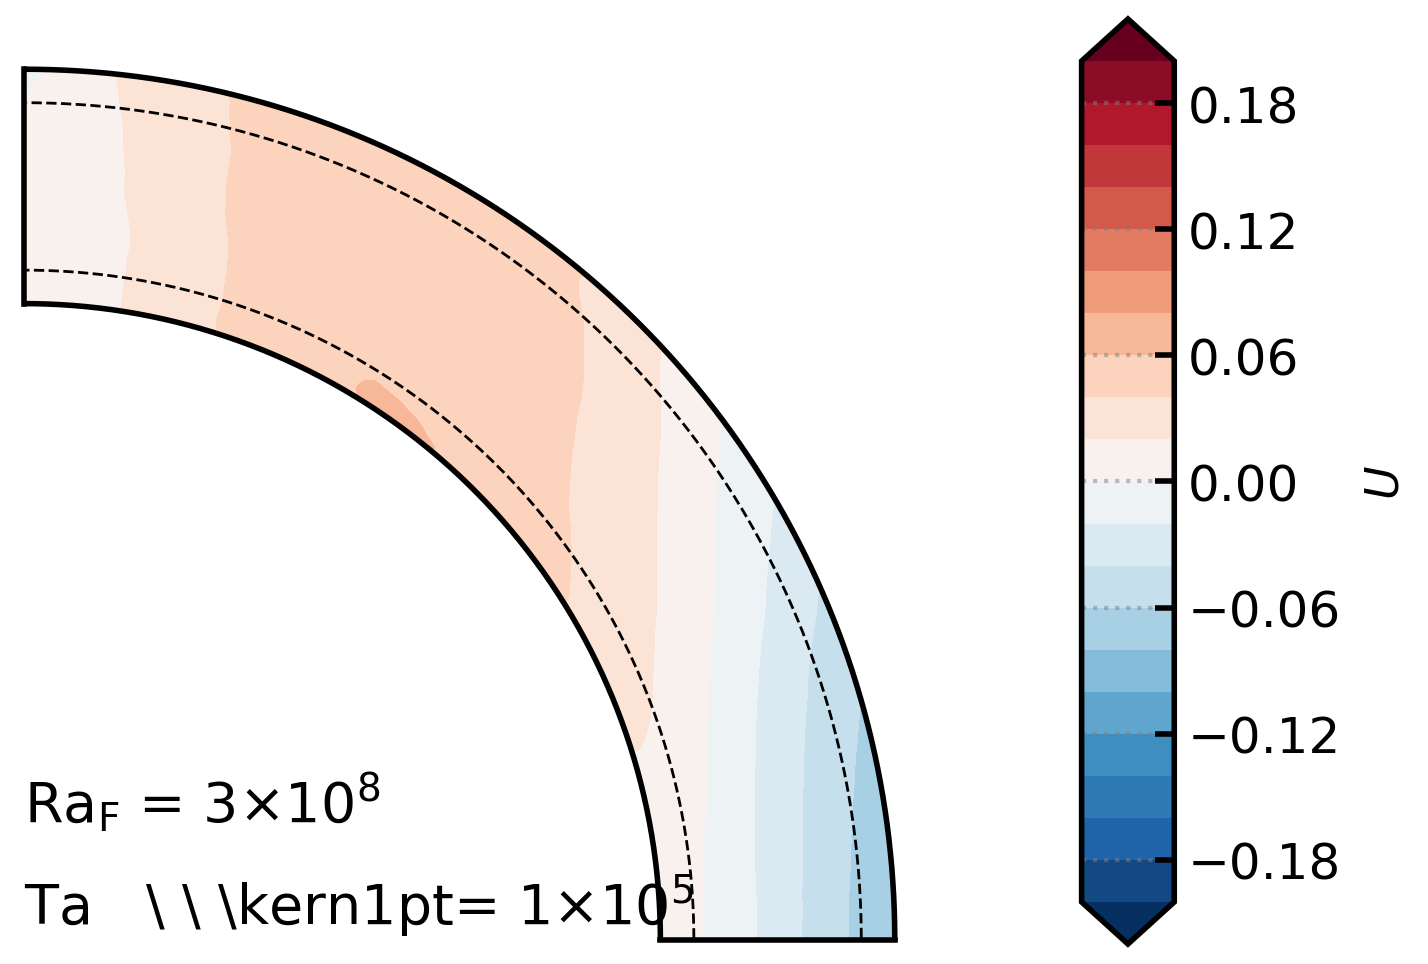

In [ ]:
grid = gs.GridSpec(1,3, wspace=0.2, hspace=0.18, bottom=0.05, top=0.975, left=0.025, right=0.85, width_ratios=[1,0,0.1])
fig = plt.figure(figsize=(7,5))



def e_to_10_fn(s1): 
    return s1.split('e')[0]+r'$\times10^{%s}$'%s1.split('e')[1]

cmap = plt.cm.RdBu_r
levels = np.linspace(-.2, .2, 21)
norm = mpl.colors.BoundaryNorm(levels, cmap.N, extend='both')

smap = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)


sintheta = np.sin(theta)
costheta = np.cos(theta)
x = sintheta * r/5 
y = costheta * r/5
        
ax = fig.add_subplot(grid[0])        
ax.set_xlim([-.005,1.1])
ax.set_ylim([-.005,1.1])
ax.set_aspect('equal', adjustable='box')        
ax.plot(x[:,0], y[:,0],'k', lw=2)
ax.plot(x[:,-1], y[:,-1],'k', lw=2)
ax.plot(x[:,-1]*5/5.2, y[:,-1]*5/5.2,'k', lw=1, ls='--')
ax.plot(x[:,-1]*4/5.2, y[:,-1]*4/5.2,'k', lw=1, ls='--')
ax.plot([0,0],[y[-1,0],y[-1,-1]], 'k', lw=2)
ax.plot([3.8/5,5.2/5],[0,0], 'k', lw=2)
ax.text(0.,0.14,r'Ra$_{\text{F}}$ = '+e_to_10_fn('3e8'), ha='left', fontsize=20)#, pad=-50)
ax.text(0.,0.02,r'Ta   \ \ \kern1pt= '+e_to_10_fn('1e5'), ha='left', fontsize=20)#, pad=-50)
ax.axis('off')
ax.contourf(x, y, u, levels=levels, cmap=cmap, norm=norm, extend='both')





cgrid = gs.GridSpecFromSubplotSpec(8,1, subplot_spec=grid[0, -1])
cax = fig.add_subplot(cgrid[:]) 
cbar=plt.colorbar(smap, cax=cax, orientation='vertical')
cbar.ax.yaxis.minorticks_off()
cbar.set_label(r'$U$')

#plt.savefig('zonal_velocity.png', dpi=500)
            